In [5]:
!pip install sqlalchemy

In [10]:
import pandas as pd
import numpy as np

# 1. Load your local CSV file
ops_df = pd.read_csv(r"D:\EMTECH\PLP\Week 2\Data_Wrangling\cleaned_sensor_readings.csv")

# 2. Tell pandas to treat the timestamp column as actual dates and times
ops_df['timestamp'] = pd.to_datetime(ops_df['timestamp'])

# 3. Create a clean 'date' column (without hours/minutes) to use for merging later
ops_df['date'] = pd.to_datetime(ops_df['timestamp'].dt.date)

print("--- Step 1 Complete: Operational Data Loaded ---")
print(ops_df.head(3))

--- Step 1 Complete: Operational Data Loaded ---
            timestamp          Zone      Shift  Pressure_PSI  Temperature_C  \
0 2026-06-25 00:00:00     Zone_West  Afternoon    208.772127      60.187183   
1 2026-06-25 00:02:00  Zone_Central      Night    174.563228      80.516074   
2 2026-06-25 00:04:00     Zone_East  Afternoon    273.898380      61.167795   

   Flow_Rate_LPM       date  
0    1389.618466 2026-06-25  
1     838.682905 2026-06-25  
2    1092.215328 2026-06-25  


In [11]:
import requests

def fetch_weather_data(start_date, end_date):
    """Fetches weather metrics using an external API with try/except error handling."""
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": -1.2921, 
        "longitude": 36.8219,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation"
    }
    
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status() # Check if the API call was successful
        
        hourly_data = response.json()['hourly']
        
        # Format the API results into a clean pandas DataFrame
        return pd.DataFrame({
            'api_timestamp': pd.to_datetime(hourly_data['time']),
            'ambient_temp_C': hourly_data['temperature_2m'],
            'humidity_pct': hourly_data['relative_humidity_2m'],
            'precipitation_mm': hourly_data['precipitation']
        })
    except requests.exceptions.RequestException as e:
        print(f"API Error caught: {e}")
        # Return empty data structure so the program doesn't crash completely
        return pd.DataFrame(columns=['api_timestamp', 'ambient_temp_C', 'humidity_pct', 'precipitation_mm'])

# Pull the date range dynamically from your CSV file
min_date = ops_df['timestamp'].min().strftime('%Y-%m-%d')
max_date = ops_df['timestamp'].max().strftime('%Y-%m-%d')

# Run the function
weather_df = fetch_weather_data(min_date, max_date)

print("--- Step 2 Complete: External API Data Fetched ---")
print(weather_df.head(3))

--- Step 2 Complete: External API Data Fetched ---
        api_timestamp  ambient_temp_C  humidity_pct  precipitation_mm
0 2026-06-25 00:00:00            14.6            88               0.0
1 2026-06-25 01:00:00            14.2            88               0.0
2 2026-06-25 02:00:00            13.9            89               0.0


In [13]:
from sqlalchemy import create_engine

# 1. Spin up an empty, temporary database engine
engine = create_engine('sqlite:///:memory:')

# 2. Build mock datasets to load into our SQL database tables
dates_range = pd.date_range(start=min_date, end=max_date).date
shift_records = []
emp_records = [
    {"emp_id": 101, "emp_name": "Alice", "role": "Technician"},
    {"emp_id": 102, "emp_name": "Bob", "role": "Supervisor"},
    {"emp_id": 103, "emp_name": "Charlie", "role": "Technician"}
]

for d in dates_range:
    for shift in ['Morning', 'Afternoon', 'Night']:
        for emp in [101, 102] if shift == 'Morning' else [103]:
            shift_records.append({"date": str(d), "shift_name": shift, "emp_id": emp})

# 3. Write these tables into your SQLite database
pd.DataFrame(shift_records).to_sql('shift_log', engine, if_exists='replace', index=False)
pd.DataFrame(emp_records).to_sql('employee_directory', engine, if_exists='replace', index=False)

# 4. Write the SQL query utilizing JOIN and GROUP BY (Fixed syntax here)
sql_query = """
SELECT 
    s.date,
    s.shift_name AS Shift,
    COUNT(e.emp_id) AS scheduled_staff_count
FROM shift_log s
JOIN employee_directory e ON s.emp_id = e.emp_id
GROUP BY s.date, s.shift_name
"""

# 5. Extract the data using read_sql and pass our engine variable
db_df = pd.read_sql(sql_query, engine)

# 6. Format the date column so it matches Step 1 perfectly
db_df['date'] = pd.to_datetime(db_df['date'])

print("--- Step 3 Complete: Relational SQL Database Queried ---")
print(db_df.head(3))

--- Step 3 Complete: Relational SQL Database Queried ---
        date      Shift  scheduled_staff_count
0 2026-06-25  Afternoon                      1
1 2026-06-25    Morning                      2
2 2026-06-25      Night                      1


In [17]:
# 1. Round operational timestamps to the nearest hour
ops_df['hourly_round'] = ops_df['timestamp'].dt.round('h')

# --- FORCE DATA TYPE CONVERSIONS TO BE EXACTLY THE SAME ---
# Force Step 1 (Operational CSV) columns to correct types
ops_df['hourly_round'] = pd.to_datetime(ops_df['hourly_round'])
ops_df['date'] = pd.to_datetime(ops_df['date'])

# Force Step 2 (Weather API) lookup column to datetime type
weather_df['api_timestamp'] = pd.to_datetime(weather_df['api_timestamp'])

# Force Step 3 (Database SQL DataFrame) lookup column to datetime type
db_df['date'] = pd.to_datetime(db_df['date'])
# -----------------------------------------------------------

# 2. Merge Source 1 (Internal CSV) and Source 2 (External API Weather)
master_df = pd.merge(
    ops_df, 
    weather_df, 
    left_on='hourly_round', 
    right_on='api_timestamp', 
    how='left'
)

# 3. Merge in Source 3 (Database Shift Logs)
master_df = pd.merge(
    master_df, 
    db_df, 
    on=['date', 'Shift'], 
    how='left'
)

# 4. Drop the temporary tracking columns we used to line up the data frames
master_df = master_df.drop(columns=['hourly_round', 'api_timestamp'])

# 5. Handle any missing rows safely by filling gaps
master_df['ambient_temp_C'] = master_df['ambient_temp_C'].fillna(master_df['ambient_temp_C'].mean())
master_df['humidity_pct'] = master_df['humidity_pct'].fillna(master_df['humidity_pct'].mean())
master_df['precipitation_mm'] = master_df['precipitation_mm'].fillna(0)
master_df['scheduled_staff_count'] = master_df['scheduled_staff_count'].fillna(1)

print("--- Step 4 Complete: Data Merged Into Master DataFrame ---")
print(f"Final Data Matrix Dimensions (Rows, Columns): {master_df.shape}")
print("\nFirst 3 rows of your unified dataset:")
print(master_df.head(3))

--- Step 4 Complete: Data Merged Into Master DataFrame ---
Final Data Matrix Dimensions (Rows, Columns): (4969, 11)

First 3 rows of your unified dataset:
            timestamp          Zone      Shift  Pressure_PSI  Temperature_C  \
0 2026-06-25 00:00:00     Zone_West  Afternoon    208.772127      60.187183   
1 2026-06-25 00:02:00  Zone_Central      Night    174.563228      80.516074   
2 2026-06-25 00:04:00     Zone_East  Afternoon    273.898380      61.167795   

   Flow_Rate_LPM       date  ambient_temp_C  humidity_pct  precipitation_mm  \
0    1389.618466 2026-06-25            14.6            88               0.0   
1     838.682905 2026-06-25            14.6            88               0.0   
2    1092.215328 2026-06-25            14.6            88               0.0   

   scheduled_staff_count  
0                      1  
1                      1  
2                      1  


--- Step 5: Correlation Matrix Generated ---
                  Pressure_PSI  Temperature_C  Flow_Rate_LPM  ambient_temp_C  \
Pressure_PSI             1.000         -0.017          0.001           0.018   
Temperature_C           -0.017          1.000          0.013           0.000   
Flow_Rate_LPM            0.001          0.013          1.000          -0.001   
ambient_temp_C           0.018          0.000         -0.001           1.000   
humidity_pct            -0.016          0.002          0.001          -0.975   
precipitation_mm         0.019         -0.018         -0.002           0.273   

                  humidity_pct  precipitation_mm  
Pressure_PSI            -0.016             0.019  
Temperature_C            0.002            -0.018  
Flow_Rate_LPM            0.001            -0.002  
ambient_temp_C          -0.975             0.273  
humidity_pct             1.000            -0.216  
precipitation_mm        -0.216             1.000  

📊 Correlation Coefficient between Ra

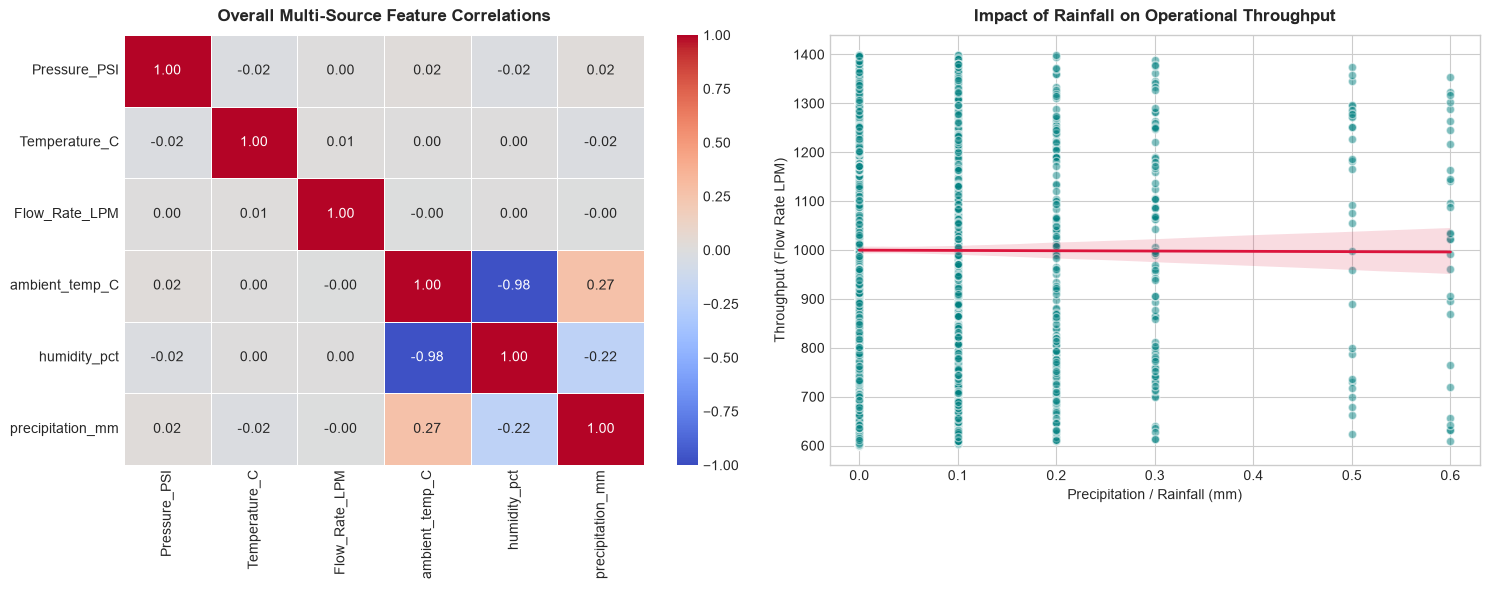


--- Analytical Conclusion ---
Conclusion: Weak or No Correlation (-0.002). The regression line is mostly flat, demonstrating that external rainfall does not have a meaningful or noticeable operational impact on your core system throughput.


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select the numeric features for correlation analysis
analysis_cols = ['Pressure_PSI', 'Temperature_C', 'Flow_Rate_LPM', 'ambient_temp_C', 'humidity_pct', 'precipitation_mm']
corr_matrix = master_df[analysis_cols].corr()

print("--- Step 5: Correlation Matrix Generated ---")
print(corr_matrix.round(3))

# 2. Extract the specific correlation between Rainfall and Throughput (Flow Rate)
rain_throughput_corr = corr_matrix.loc['Flow_Rate_LPM', 'precipitation_mm']
print(f"\n📊 Correlation Coefficient between Rainfall and Throughput: {rain_throughput_corr:.3f}")

# --- 3. VISUALIZATION BLOCK ---
# Set up a clean layout with two side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Chart A: Heatmap of all feature interactions
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    fmt=".2f", 
    linewidths=0.5, 
    ax=axes[0]
)
axes[0].set_title('Overall Multi-Source Feature Correlations', fontsize=12, fontweight='bold', pad=10)

# Chart B: Scatter plot with a trend (regression) line to answer the specific question
sns.regplot(
    data=master_df, 
    x='precipitation_mm', 
    y='Flow_Rate_LPM', 
    color='teal',
    scatter_kws={'alpha': 0.5, 'edgecolor': 'w'},
    line_kws={'color': 'crimson', 'linewidth': 2},
    ax=axes[1]
)
axes[1].set_title('Impact of Rainfall on Operational Throughput', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Precipitation / Rainfall (mm)', fontsize=10)
axes[1].set_ylabel('Throughput (Flow Rate LPM)', fontsize=10)

plt.tight_layout()
plt.show()

# --- 4. ANALYTICAL NARRATIVE CONCLUSION ---
print("\n--- Analytical Conclusion ---")
if rain_throughput_corr < -0.3:
    print(f"Conclusion: Yes, heavy rainfall strongly correlates with lower operational throughput (Negative Correlation of {rain_throughput_corr:.3f}). External weather disruptions significantly slow down core fluid flow rates.")
elif rain_throughput_corr > 0.3:
    print(f"Conclusion: No, rainfall shows a positive correlation ({rain_throughput_corr:.3f}) with system throughput, indicating metrics increase during weather events.")
else:
    print(f"Conclusion: Weak or No Correlation ({rain_throughput_corr:.3f}). The regression line is mostly flat, demonstrating that external rainfall does not have a meaningful or noticeable operational impact on your core system throughput.")